# Day 5：从实验轨迹学习局部 Surrogate Model

今天的核心能力是：不是直接相信隐藏环境，而是用已有实验数据训练一个
局部预测模型，再用模型推荐下一批候选实验。


In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(5)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day05


In [2]:
tu.display_learning_goal(
    5,
    "局部 world model",
    [
        "把配方参数编码成机器学习特征。",
        "用随机森林训练 score surrogate。",
        "在候选池中按预测分数推荐下一次实验。",
        "比较 surrogate 推荐和真实 final assay 结果。",
    ],
)


In [3]:
tu.display_api_card()


In [4]:
tu.display_student_checkpoint(
    5,
    [
        'one trajectory table or JSONL artifact',
        'one figure generated from your own run',
        'one chemical hypothesis',
        'one proposed next experiment',
        'one note on how GPT or another assistant was used',
    ],
)


,recipe_index,temperature_C,time_h,initial_concentration_M,catalyst,solvent,yield,risk,score
0,0,154.7202,1.8595,1.6740,cat_d,acetonitrile,0.0000,0.5245,0.0000
1,1,56.3104,5.5900,1.6993,cat_c,toluene,0.2751,0.2837,0.1538
2,2,139.0399,2.8712,1.1939,cat_d,toluene,0.0038,0.4370,0.0000
3,3,152.0126,1.3737,1.5166,cat_b,toluene,0.0066,0.5289,0.0000
4,4,67.1337,6.8626,0.6820,cat_a,acetonitrile,0.6334,0.1514,0.4732
5,5,78.6969,2.4389,1.2511,cat_c,acetonitrile,0.3960,0.2567,0.2678
6,6,58.5310,2.1858,1.7528,cat_b,ethanol,0.7288,0.2534,0.5069
7,7,57.9298,1.3101,0.5729,cat_c,acetonitrile,0.6247,0.1278,0.4777
8,8,140.5077,6.2642,0.7451,cat_b,ethanol,0.0175,0.3370,0.0000
9,9,92.5437,4.7002,0.8092,cat_b,water,0.3761,0.1489,0.2728


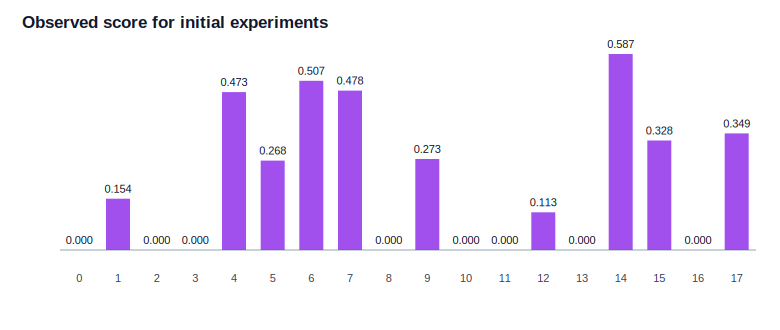

In [5]:
from chemworld.core.actions import action_to_vector

recipes = tu.sample_recipes(seed=10, count=18)
rows = []
for index, recipe in enumerate(recipes):
    result = tu.run_recipe(recipe, seed=100 + index)
    result["recipe_index"] = index
    rows.append(result)

train_df = pd.DataFrame(rows)
display(
    train_df[
        [
            "recipe_index",
            "temperature_C",
            "time_h",
            "initial_concentration_M",
            "catalyst",
            "solvent",
            "yield",
            "risk",
            "score",
        ]
    ].head(10)
)
display(
    tu.bar_svg(
        train_df["recipe_index"].astype(str).tolist(),
        train_df["score"].astype(float).tolist(),
        title="Observed score for initial experiments",
        color="#9333ea",
    )
)


,observed,predicted
0,0.0000,0.0596
1,0.1538,0.2011
2,0.0000,0.0857
3,0.0000,0.0459
4,0.4732,0.3829


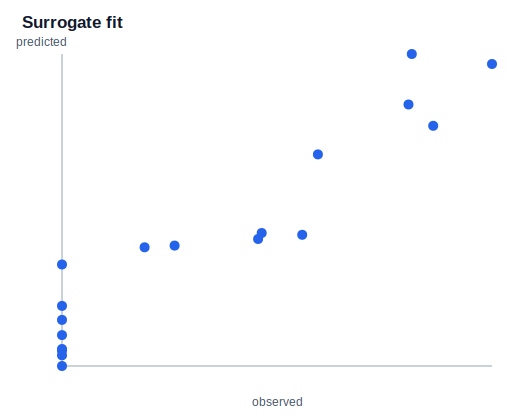

In [6]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

x_train = np.vstack([action_to_vector(recipe) for recipe in recipes])
y_train = train_df["score"].astype(float).to_numpy()

model = RandomForestRegressor(
    n_estimators=160,
    min_samples_leaf=2,
    random_state=5,
)
model.fit(x_train, y_train)

fit_df = pd.DataFrame(
    {
        "observed": y_train,
        "predicted": model.predict(x_train),
    }
)
display(fit_df.head())
display(tu.scatter_svg(fit_df, x="observed", y="predicted", title="Surrogate fit"))


In [7]:
candidates = tu.sample_recipes(seed=99, count=80)
x_candidates = np.vstack([action_to_vector(recipe) for recipe in candidates])
predicted = model.predict(x_candidates)

candidate_df = pd.DataFrame([tu.format_recipe(recipe) for recipe in candidates])
candidate_df['predicted_score'] = predicted
top_candidates = (
    candidate_df.sort_values('predicted_score', ascending=False)
    .head(8)
    .reset_index(drop=True)
)
display(top_candidates)

best_index = int(np.argmax(predicted))
recommended_recipe = candidates[best_index]
tu.show_json_panel('Recommended recipe', tu.format_recipe(recommended_recipe))


,temperature_C,time_h,initial_concentration_M,stirring_rpm,catalyst,solvent,predicted_score
0,60.0481,0.8998,0.2903,542.1833,cat_d,ethanol,0.4487
1,42.5173,3.7372,0.4435,1098.3663,cat_a,acetonitrile,0.4458
2,44.7876,3.8120,0.6124,1073.6734,cat_b,ethanol,0.4379
3,62.1788,5.4900,0.3141,745.0612,cat_d,acetonitrile,0.3934
4,63.2416,0.7845,0.5789,204.7121,cat_d,water,0.3927
5,53.3827,6.7449,0.5621,224.8718,cat_a,acetonitrile,0.3721
6,58.5835,7.9533,0.1103,1025.0552,cat_c,toluene,0.3265
7,61.5549,7.0038,0.1251,309.1689,cat_d,toluene,0.3095


In [8]:
gpt_prompt_template = {
    'role': 'You propose chemically plausible next experiments.',
    'return_format': [
        {
            'temperature': 'degC in [40, 160]',
            'time': 'h in [0.25, 8.0]',
            'initial_concentration': 'mol/L in [0.10, 2.00]',
            'stirring_speed': 'rpm in [100, 1200]',
            'catalyst': 'integer 0..3',
            'solvent': 'integer 0..3',
            'rationale': 'one sentence',
        }
    ],
    'validator': 'ChemWorld canonicalize_action plus final assay replay',
}
tu.show_json_panel('Structured GPT proposal template', gpt_prompt_template)


,source,score,yield,risk
0,best_initial_observed,0.5872,0.7947,0.1396
1,surrogate_recommendation,0.5705,0.7292,0.0763


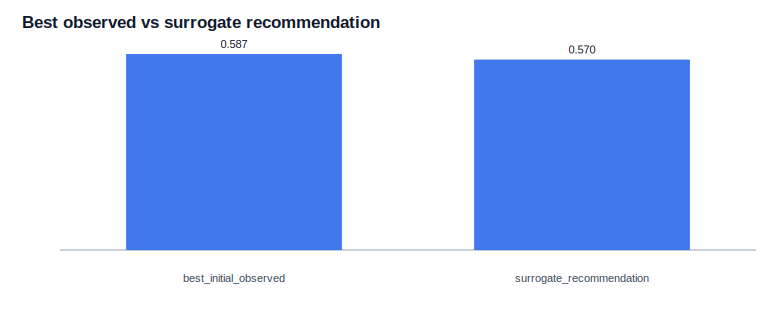

In [9]:
recommended_result = tu.run_recipe(recommended_recipe, seed=777)
best_initial = train_df.iloc[int(train_df["score"].to_numpy().argmax())]
comparison = pd.DataFrame(
    [
        {
            "source": "best_initial_observed",
            "score": float(train_df["score"].max()),
            "yield": float(best_initial["yield"]),
            "risk": float(best_initial["risk"]),
        },
        {
            "source": "surrogate_recommendation",
            "score": float(recommended_result["score"]),
            "yield": float(recommended_result["yield"]),
            "risk": float(recommended_result["risk"]),
        },
    ]
)
display(comparison)
display(
    tu.bar_svg(
        comparison["source"].tolist(),
        comparison["score"].tolist(),
        title="Best observed vs surrogate recommendation",
        color="#2563eb",
    )
)


## 当天练习

surrogate model 不是 oracle。请回答：

- 它最容易在哪些区域外推失败？
- 如果你还有 6 次实验预算，会保守 exploitation，还是探索高不确定区域？
- 安全风险应作为预测目标、约束，还是惩罚项？
